In [193]:
import pandas as pd

In [195]:
# Baca file CSV
df = pd.read_csv("data_news/news.csv")

# Ubah kolom 'tgl' ke datetime
df['tgl'] = pd.to_datetime(df['tgl'])
df = df.sort_values(by='tgl', ascending=True)
#df['tgl'] = df['tgl'].dt.tz_localize('Asia/Jakarta')
df = df[df['tgl'] >= '2020-01-04']

df['tgl_only'] = df['tgl'].dt.date
df['jam_only'] = df['tgl'].dt.time

filter_list = ['politik', 'geo politik', 'ekonomi', 'saham', 'emas']
df = df[df['query'].isin(filter_list)]

In [196]:
df

,tgl,judul,rss,nama_sumber,link_sumber,query,link_berita,konten,ringkasan,tgl_only,jam_only
1376,2025-02-19 08:00:00,Indonesia Perlu Bersikap di Tengah Pusaran Din...,Google News,UGM,https://ugm.ac.id,geo politik,https://news.google.com/rss/articles/CBMingFBV...,NaN,NaN,2025-02-19,08:00:00
1431,2025-02-21 08:00:00,Dinamika Geopolitik Global dan Tantangan Dunia...,Google News,suaramuhammadiyah.id,https://www.suaramuhammadiyah.id,geo politik,https://news.google.com/rss/articles/CBMilAFBV...,NaN,NaN,2025-02-21,08:00:00
1421,2025-02-21 08:00:00,Dinamika Geopolitik Global dan Tantangan Dunia...,Google News,suaramuhammadiyah.id,https://suaramuhammadiyah.id,geo politik,https://news.google.com/rss/articles/CBMijwFBV...,NaN,NaN,2025-02-21,08:00:00
2975,2025-05-14 07:00:00,MK: Partai Politik Berperan Penting sebagai Pi...,Google News,Mahkamah Konstitusi,https://www.mkri.id,politik,https://news.google.com/rss/articles/CBMitwFBV...,NaN,NaN,2025-05-14,07:00:00
3124,2025-05-20 07:00:00,"Dibuka Presiden RI Prabowo Subianto, Bupati Ka...",Google News,mediacenter.kamparkab.go.id,https://mediacenter.kamparkab.go.id,geo politik,https://news.google.com/rss/articles/CBMi8gFBV...,NaN,NaN,2025-05-20,07:00:00
...,...,...,...,...,...,...,...,...,...,...,...
18350,2025-11-06 04:33:00,"Ekonomi RI Tumbuh 5,04 Persen di Kuartal III 2...",Google News,Kompas.com,https://money.kompas.com,ekonomi,https://news.google.com/rss/articles/CBMivwFBV...,NaN,NaN,2025-11-06,04:33:00
18486,2025-11-06 04:39:34,"Emas Antam, UBS dan Galeri24 Turun Segini, Pre...",Google News,Tribunnewssultra.com,https://sultra.tribunnews.com,emas,https://news.google.com/rss/articles/CBMivgFBV...,NaN,NaN,2025-11-06,04:39:34
18353,2025-11-06 04:40:00,Ekonomi RI Kembali Tunjukkan Ketahanan dan Day...,Google News,Warta Ekonomi,https://wartaekonomi.co.id,ekonomi,https://news.google.com/rss/articles/CBMinAFBV...,NaN,NaN,2025-11-06,04:40:00
18339,2025-11-06 04:44:42,"Program Kerja Sama Pemasaran Produk IKM, Wawak...",Google News,Pemerintah Kota Tanjungpinang,https://www.tanjungpinangkota.go.id,ekonomi,https://news.google.com/rss/articles/CBMi5wFBV...,NaN,NaN,2025-11-06,04:44:42


In [197]:
print(df.dtypes)

tgl            datetime64[ns]
judul                  object
rss                    object
nama_sumber            object
link_sumber            object
query                  object
link_berita            object
konten                float64
ringkasan             float64
tgl_only               object
jam_only               object
dtype: object


In [198]:
news = df[['tgl_only', 'jam_only','nama_sumber', 'judul']].copy()
news

,tgl_only,jam_only,nama_sumber,judul
1376,2025-02-19,08:00:00,UGM,Indonesia Perlu Bersikap di Tengah Pusaran Din...
1431,2025-02-21,08:00:00,suaramuhammadiyah.id,Dinamika Geopolitik Global dan Tantangan Dunia...
1421,2025-02-21,08:00:00,suaramuhammadiyah.id,Dinamika Geopolitik Global dan Tantangan Dunia...
2975,2025-05-14,07:00:00,Mahkamah Konstitusi,MK: Partai Politik Berperan Penting sebagai Pi...
3124,2025-05-20,07:00:00,mediacenter.kamparkab.go.id,"Dibuka Presiden RI Prabowo Subianto, Bupati Ka..."
...,...,...,...,...
18350,2025-11-06,04:33:00,Kompas.com,"Ekonomi RI Tumbuh 5,04 Persen di Kuartal III 2..."
18486,2025-11-06,04:39:34,Tribunnewssultra.com,"Emas Antam, UBS dan Galeri24 Turun Segini, Pre..."
18353,2025-11-06,04:40:00,Warta Ekonomi,Ekonomi RI Kembali Tunjukkan Ketahanan dan Day...
18339,2025-11-06,04:44:42,Pemerintah Kota Tanjungpinang,"Program Kerja Sama Pemasaran Produk IKM, Wawak..."


# Ambil tanggal unik
unique_dates = news['tgl_only'].unique()
unique_dates_str = [str(t) for t in unique_dates]
print(len(unique_dates_str))
print(unique_dates_str[:100])

In [199]:
news

,tgl_only,jam_only,nama_sumber,judul
1376,2025-02-19,08:00:00,UGM,Indonesia Perlu Bersikap di Tengah Pusaran Din...
1431,2025-02-21,08:00:00,suaramuhammadiyah.id,Dinamika Geopolitik Global dan Tantangan Dunia...
1421,2025-02-21,08:00:00,suaramuhammadiyah.id,Dinamika Geopolitik Global dan Tantangan Dunia...
2975,2025-05-14,07:00:00,Mahkamah Konstitusi,MK: Partai Politik Berperan Penting sebagai Pi...
3124,2025-05-20,07:00:00,mediacenter.kamparkab.go.id,"Dibuka Presiden RI Prabowo Subianto, Bupati Ka..."
...,...,...,...,...
18350,2025-11-06,04:33:00,Kompas.com,"Ekonomi RI Tumbuh 5,04 Persen di Kuartal III 2..."
18486,2025-11-06,04:39:34,Tribunnewssultra.com,"Emas Antam, UBS dan Galeri24 Turun Segini, Pre..."
18353,2025-11-06,04:40:00,Warta Ekonomi,Ekonomi RI Kembali Tunjukkan Ketahanan dan Day...
18339,2025-11-06,04:44:42,Pemerintah Kota Tanjungpinang,"Program Kerja Sama Pemasaran Produk IKM, Wawak..."


In [200]:
import pandas as pd

# Baca file CSV
stock = pd.read_csv("data_news/ihsg.csv")

# Konversi kolom Date ke datetime dengan format hari/bulan/tahun
stock['Date'] = pd.to_datetime(stock['Date'], dayfirst=True, errors='coerce')

# Tambahkan timezone Asia/Jakarta
#stock['Date'] = stock['Date'].dt.tz_localize('Asia/Jakarta')

# Urutkan berdasarkan tanggal
stock = stock.sort_values(by='Date', ascending=True)

# Bersihkan dan ubah kolom Perubahan%
stock["Perubahan%"] = (
    stock["Perubahan%"]
    .astype(str)                        # pastikan string
    .str.replace("%", "", regex=False)  # hilangkan tanda persen
    .str.replace(",", ".", regex=False) # ubah koma jadi titik
    .astype(float)                      # ubah ke float
)

# Fungsi status
def get_status(x):
    if x < 0:
        return "bad"
    else:
        return "good"

# Tambahkan kolom Status
stock["Status"] = stock["Perubahan%"].apply(get_status)

# Tampilkan hasil
stock


,Date,Close,Open,High,Close.1,Volume,Perubahan%,Status
2685,2014-10-06,"5.000,14","4.975,20","5.006,34","4.946,70","2,39B",1.03,good
2684,2014-10-07,"5.032,84","5.017,15","5.048,23","5.000,16","3,87B",0.65,good
2683,2014-10-08,"4.958,52","4.992,42","5.004,56","4.958,52","2,99B",-1.48,bad
2682,2014-10-09,"4.993,88","4.993,23","5.014,51","4.992,67","3,14B",0.71,good
2681,2014-10-10,"4.962,96","4.948,28","4.971,03","4.933,39","2,81B",-0.62,bad
...,...,...,...,...,...,...,...,...
4,2025-10-31,"8.163,88","8.202,52","8.215,55","8.144,08","24,54B",-0.25,bad
3,2025-11-03,"8.275,08","8.208,03","8.282,16","8.201,36","10,10B",1.36,good
2,2025-11-04,"8.241,91","8.275,95","8.317,08","8.225,91","25,46B",-0.40,bad
1,2025-11-05,"8.318,53","8.213,60","8.318,53","8.181,90","33,38B",0.93,good


In [201]:
import pandas as pd
from datetime import timedelta

def get_daily_data_no_merged(date_str: str, news: pd.DataFrame, stock: pd.DataFrame):
    cutoff = pd.to_datetime("15:00:00").time()
    
    news['tgl_only'] = pd.to_datetime(news['tgl_only'])
    news_filtered = news[(news['tgl_only'] == date_str) & (news['jam_only'] <= cutoff)]

    stock['Date']    = pd.to_datetime(stock['Date'])
    stock_filtered = stock[stock['Date'] == date_str]

    return news_filtered, stock_filtered


In [202]:
berita, saham = get_daily_data_no_merged("2020-02-20", news, stock)
berita

,tgl_only,jam_only,nama_sumber,judul


In [203]:
saham

,Date,Close,Open,High,Close.1,Volume,Perubahan%,Status
1377,2020-02-20,"5.942,49","5.941,45","5.960,71","5.929,15","3,74B",0.23,good


In [204]:
import pandas as pd
from datetime import timedelta

# Contoh: news dan stock sudah dibaca sebelumnya
# news = pd.read_csv("news.csv")
# stock = pd.read_csv("stock.csv")

# Pastikan format datetime benar
news['tgl_only'] = pd.to_datetime(news['tgl_only'])
stock['Date'] = pd.to_datetime(stock['Date'])

# Jika jam masih string, ubah jadi time
news['jam_only'] = pd.to_datetime(news['jam_only'], format='%H:%M:%S').dt.time

# Tentukan cutoff jam perdagangan (15:00)
cutoff = pd.to_datetime("15:00:00").time()

# Buat kolom acuan join (tgl_join)
def find_stock_date(row):
    if row['jam_only'] > cutoff:
        # berita di atas jam 15:00 → pakai hari berikutnya
        next_day = row['tgl_only'] + timedelta(days=1)
        return next_day
    else:
        # berita di bawah jam 15:00 → pakai hari yang sama
        return row['tgl_only']

news['tgl_join'] = news.apply(find_stock_date, axis=1)

# Gabungkan berdasarkan tanggal acuan
merged = pd.merge(
    news,
    stock[['Date', 'Perubahan%', 'Status']],
    left_on='tgl_join',
    right_on='Date',
    how='left'
)

# Hapus kolom tambahan
merged = merged.drop(columns=['Date'])

# Opsional: isi NaN jadi 'unknown'
#merged['Status'] = merged['Status'].fillna('unknown')
merged = merged.dropna(subset=['Status'])

merged[['tgl_only', 'jam_only','tgl_join', 'judul',  'Status']]


,tgl_only,jam_only,tgl_join,judul,Status
0,2025-02-19,08:00:00,2025-02-19,Indonesia Perlu Bersikap di Tengah Pusaran Din...,bad
1,2025-02-21,08:00:00,2025-02-21,Dinamika Geopolitik Global dan Tantangan Dunia...,good
2,2025-02-21,08:00:00,2025-02-21,Dinamika Geopolitik Global dan Tantangan Dunia...,good
3,2025-05-14,07:00:00,2025-05-14,MK: Partai Politik Berperan Penting sebagai Pi...,good
4,2025-05-20,07:00:00,2025-05-20,"Dibuka Presiden RI Prabowo Subianto, Bupati Ka...",bad
...,...,...,...,...,...
2049,2025-11-06,04:33:00,2025-11-06,"Ekonomi RI Tumbuh 5,04 Persen di Kuartal III 2...",good
2050,2025-11-06,04:39:34,2025-11-06,"Emas Antam, UBS dan Galeri24 Turun Segini, Pre...",good
2051,2025-11-06,04:40:00,2025-11-06,Ekonomi RI Kembali Tunjukkan Ketahanan dan Day...,good
2052,2025-11-06,04:44:42,2025-11-06,"Program Kerja Sama Pemasaran Produk IKM, Wawak...",good


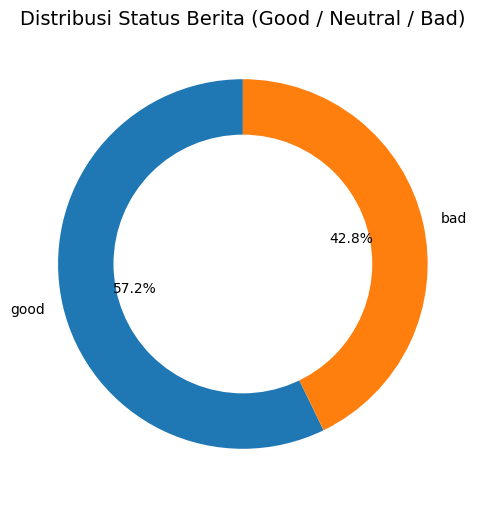

In [205]:
import matplotlib.pyplot as plt

# Hitung jumlah tiap kategori status
status_counts = merged['Status'].value_counts()

# Buat diagram donat
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)  # Membuat donat (lubang di tengah)
)

# Tambahkan lingkaran putih di tengah
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Judul
plt.title('Distribusi Status Berita (Good / Neutral / Bad)', fontsize=14)

# Tampilkan grafik
plt.show()


In [206]:
from transformers import BertTokenizer, AutoModel

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

pretrained_model = "indobenchmark/indobert-lite-base-p2"
tokenizer = BertTokenizer.from_pretrained(pretrained_model)
m_bert    = AutoModel.from_pretrained(pretrained_model)
m_bert.to(device)
m_bert.eval()

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'AlbertTokenizerFast'. 
The class this function is called from is 'BertTokenizer'.


AlbertModel(
  (embeddings): AlbertEmbeddings(
    (word_embeddings): Embedding(30000, 128, padding_idx=0)
    (position_embeddings): Embedding(512, 128)
    (token_type_embeddings): Embedding(2, 128)
    (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0, inplace=False)
  )
  (encoder): AlbertTransformer(
    (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
    (albert_layer_groups): ModuleList(
      (0): AlbertLayerGroup(
        (albert_layers): ModuleList(
          (0): AlbertLayer(
            (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (attention): AlbertSdpaAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (attention_dropout): Dropout(p=0, inplace=False)
  

In [207]:
import torch
import numpy as np

def to_vec(text, norm=True):
    # Tokenisasi input
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=64
    ).to(device)

    # Dapatkan embedding dari model
    with torch.no_grad():
        outputs = m_bert(**inputs)
        vector = outputs.pooler_output  # [1, 768]

    # Pindahkan ke CPU dan ubah jadi array 1D
    vec = vector.cpu().numpy().flatten()

    if(norm):
        # --- Normalisasi ke 0–1 ---
        min_val = np.min(vec)
        max_val = np.max(vec)
    
        if max_val != min_val:
            vec = (vec - min_val) / (max_val - min_val)
        else:
            vec = np.zeros_like(vec)  # jika semua nilai sama, buat nol semua

    return vec


#v = to_vec('hallo', norm=False)
#print(len(v))
#print(v[:100])

In [208]:
from tqdm import tqdm
import pandas as pd

# Aktifkan tqdm untuk pandas
tqdm.pandas()

# One-hot encoding pada kolom 'Poli'
label = pd.get_dummies(merged['Status']).astype(int)
merged = pd.concat([merged, label], axis=1)
merged['vectors'] = merged.progress_apply(
    lambda row: to_vec(row['judul']),
    axis=1
)

merged

100%|██████████| 1988/1988 [00:28<00:00, 68.93it/s]


,tgl_only,jam_only,nama_sumber,judul,tgl_join,Perubahan%,Status,bad,good,vectors
0,2025-02-19,08:00:00,UGM,Indonesia Perlu Bersikap di Tengah Pusaran Din...,2025-02-19,-1.14,bad,1,0,"[0.3150496, 0.56173855, 0.99499613, 0.99968696..."
1,2025-02-21,08:00:00,suaramuhammadiyah.id,Dinamika Geopolitik Global dan Tantangan Dunia...,2025-02-21,0.22,good,0,1,"[0.25412878, 0.6115836, 0.9730186, 0.9996388, ..."
2,2025-02-21,08:00:00,suaramuhammadiyah.id,Dinamika Geopolitik Global dan Tantangan Dunia...,2025-02-21,0.22,good,0,1,"[0.25412878, 0.6115836, 0.9730186, 0.9996388, ..."
3,2025-05-14,07:00:00,Mahkamah Konstitusi,MK: Partai Politik Berperan Penting sebagai Pi...,2025-05-14,2.15,good,0,1,"[0.17303818, 0.50862825, 0.98413414, 0.9992742..."
4,2025-05-20,07:00:00,mediacenter.kamparkab.go.id,"Dibuka Presiden RI Prabowo Subianto, Bupati Ka...",2025-05-20,-0.65,bad,1,0,"[0.18963555, 0.4667111, 0.99726546, 0.9994264,..."
...,...,...,...,...,...,...,...,...,...,...
2049,2025-11-06,04:33:00,Kompas.com,"Ekonomi RI Tumbuh 5,04 Persen di Kuartal III 2...",2025-11-06,0.40,good,0,1,"[0.3673637, 0.49882555, 0.99410135, 0.99928874..."
2050,2025-11-06,04:39:34,Tribunnewssultra.com,"Emas Antam, UBS dan Galeri24 Turun Segini, Pre...",2025-11-06,0.40,good,0,1,"[0.2529003, 0.6062105, 0.99625474, 0.9988054, ..."
2051,2025-11-06,04:40:00,Warta Ekonomi,Ekonomi RI Kembali Tunjukkan Ketahanan dan Day...,2025-11-06,0.40,good,0,1,"[0.30064544, 0.5214554, 0.99499065, 0.99973565..."
2052,2025-11-06,04:44:42,Pemerintah Kota Tanjungpinang,"Program Kerja Sama Pemasaran Produk IKM, Wawak...",2025-11-06,0.40,good,0,1,"[0.14710566, 0.46064585, 0.99483484, 0.9995302..."


In [209]:
import torch.nn.functional as F
import torch
from torch.utils.data import Dataset
import ast




class IndoBertDataset(Dataset):
    def __init__(self, df, labels, device=None):
        self.df = df.reset_index(drop=True)
        self.labels = labels
        self.device = device

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # --- Ambil vector ---
        vec = row["vectors"]

        # Jika string format numpy array -> ubah ke np.array
        if isinstance(vec, str):
            vec = np.fromstring(vec.strip("[]"), sep=" ")

        if isinstance(vec, np.ndarray):
            x = torch.from_numpy(vec).float()
        else:
            x = torch.tensor(vec, dtype=torch.float)

        # --- Normalisasi ke -1..1 ---
        '''
        if x.numel() > 0:  # pastikan tidak kosong
            min_val, max_val = x.min(), x.max()
            if (max_val - min_val) > 0:  # hindari div 0
                x = 2 * (x - min_val) / (max_val - min_val) - 1
        '''

        # --- Ambil target y ---
        y = torch.tensor([float(row[label]) for label in self.labels], dtype=torch.float)

        if self.device:
            x = x.to(self.device)
            y = y.to(self.device)

        return x, y


In [210]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(merged, test_size=0.3, random_state=42,shuffle=True)


from torch.utils.data import DataLoader
labels = ['bad', 'good']
train_dataset = IndoBertDataset(train_df, labels, device=device)
test_dataset = IndoBertDataset(test_df, labels, device=device)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

#train_dataset.__getitem__(3)
len(test_dataset[0][1])

2

In [211]:
from jcopdl.callback import Callback, set_config

config = set_config({
    "labels"         : labels,
    "threshold"      : 0.5,
    "input_dim"      : len(test_dataset[0][0]),
    "hidden_dims"    : [128,64],
    "output_dim"     : len(test_dataset[0][1]),
    "dropout"        : 0.2,
    "activation"     : "relu",
    "early_stop_patience" : 30,
    "col_target"     : ['bad', 'good'],
    "feature_cols"   : ['vectors']
})
config

Config(activation=relu, col_target=['bad', 'good'], dropout=0.2, early_stop_patience=30, feature_cols=['vectors'], hidden_dims=[128, 64], input_dim=768, labels=['bad', 'good'], output_dim=2, threshold=0.5)

In [212]:
from class_lib import MultiLabel1DClassifier
from torch import optim, nn
from jcopdl.callback import Callback
root_folder = "multi-label-clasification"
#Model
model = MultiLabel1DClassifier(input_dim=config.input_dim, hidden_dims=config.hidden_dims, output_dim=config.output_dim, dropout=config.dropout, activation=config.activation).to(device)

#Criterion
criterion = nn.BCELoss()

# --- Pilihan Optimizer ---
# AdamW
optimizer_adamw = optim.AdamW(model.parameters(), lr=0.001)
# Adam
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
# SGD (Stochastic Gradient Descent)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# RMSprop
optimizer_rmsprop = optim.RMSprop(model.parameters(), lr=0.001, momentum=0.9)
# Adagrad
optimizer_adagrad = optim.Adagrad(model.parameters(), lr=0.01)
# Adadelta
optimizer_adadelta = optim.Adadelta(model.parameters(), lr=1.0)
# ASGD (Averaged SGD)
optimizer_asgd = optim.ASGD(model.parameters(), lr=0.01)

# --- Contoh cara memilih salah satu ---
optim = optimizer_adamw  # misalnya kita pakai RAdam

#Callback
callback = Callback(model, config, outdir=root_folder,early_stop_patience=config.early_stop_patience)

─────────────────────────────────────────────────── 🚀 EPOCH 1 ────────────────────────────────────────────────────

test: 100%|██████████| 10/10 [00:00<00:00, 56.16it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6865 │ 0.6872 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4313 │ 0.4405 │ │  bad  │  0.5595  │
│ Subset Accuracy  │ 0.5536 │ 0.5595 │ │ good  │  0.5595  │
│ Micro F1         │ 0.5717 │ 0.5595 │ └───────┴──────────┘
│ Macro F1         │ 0.3898 │ 0.3588 │                     
│ Overall Accuracy │ 0.5687 │ 0.5595 │                     
└──────────────────┴────────┴────────┘


Epoch     1
Train_cost  = 0.6865 | Test_cost  = 0.6872 | Train_score = 0.5687 | Test_score = 0.5595 |


─────────────────────────────────────────────────── 🚀 EPOCH 2 ────────────────────────────────────────────────────

...


Epoch    19
Train_cost  = 0.6793 | Test_cost  = 0.6889 | Train_score = 0.5773 | Test_score = 0.5595 |
==> EarlyStop patience = 18 | Best test_score: 0.5595


─────────────────────────────────────────────────── 🚀 EPOCH 20 ───────────────────────────────────────────────────

test: 100%|██████████| 10/10 [00:00<00:00, 79.80it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6806 │ 0.6867 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4227 │ 0.4405 │ │  bad  │  0.5595  │
│ Subset Accuracy  │ 0.5773 │ 0.5595 │ │ good  │  0.5595  │
│ Micro F1         │ 0.5773 │ 0.5595 │ └───────┴──────────┘
│ Macro F1         │ 0.3660 │ 0.3588 │                     
│ Overall Accuracy │ 0.5773 │ 0.5595 │                     
└──────────────────┴────────┴────────┘


Epoch    20
Train_cost  = 0.6806 | Test_cost  = 0.6867 | Train_score = 0.5773 | Test_score = 0.5595 |


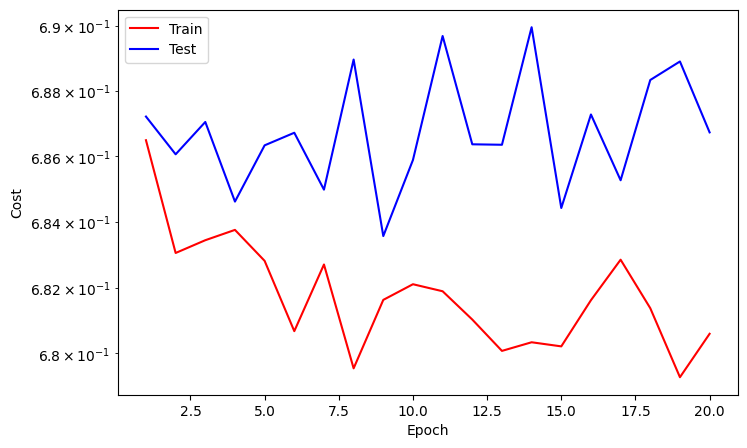

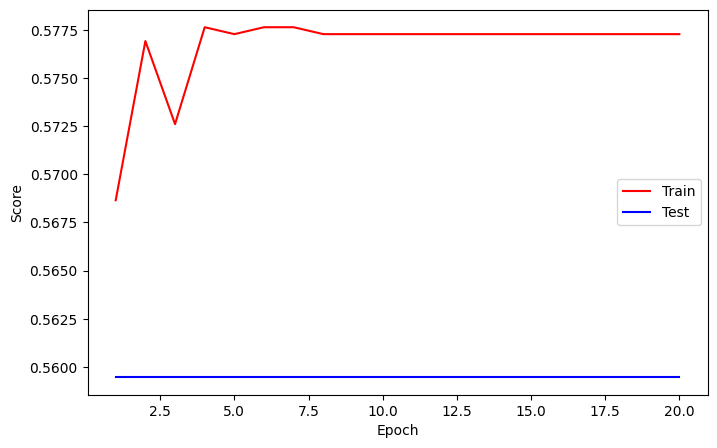

==> EarlyStop patience = 19 | Best test_score: 0.5595


─────────────────────────────────────────────────── 🚀 EPOCH 21 ───────────────────────────────────────────────────

test: 100%|██████████| 10/10 [00:00<00:00, 68.05it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6813 │ 0.6837 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4227 │ 0.4405 │ │  bad  │  0.5595  │
│ Subset Accuracy  │ 0.5773 │ 0.5595 │ │ good  │  0.5595  │
│ Micro F1         │ 0.5773 │ 0.5595 │ └───────┴──────────┘
│ Macro F1         │ 0.3660 │ 0.3588 │                     
│ Overall Accuracy │ 0.5773 │ 0.5595 │                     
└──────────────────┴────────┴────────┘


Epoch    21
Train_cost  = 0.6813 | Test_cost  = 0.6837 | Train_score = 0.5773 | Test_score = 0.5595 |
==> EarlyStop patience = 20 | Best test_score: 0.5595


...


Epoch    30
Train_cost  = 0.6785 | Test_cost  = 0.6920 | Train_score = 0.5773 | Test_score = 0.5595 |
==> EarlyStop patience = 29 | Best test_score: 0.5595


─────────────────────────────────────────────────── 🚀 EPOCH 31 ───────────────────────────────────────────────────

test: 100%|██████████| 10/10 [00:00<00:00, 60.18it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6790 │ 0.6887 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4227 │ 0.4405 │ │  bad  │  0.5595  │
│ Subset Accuracy  │ 0.5773 │ 0.5595 │ │ good  │  0.5595  │
│ Micro F1         │ 0.5773 │ 0.5595 │ └───────┴──────────┘
│ Macro F1         │ 0.3660 │ 0.3588 │                     
│ Overall Accuracy │ 0.5773 │ 0.5595 │                     
└──────────────────┴────────┴────────┘


Epoch    31
Train_cost  = 0.6790 | Test_cost  = 0.6887 | Train_score = 0.5773 | Test_score = 0.5595 |
==> EarlyStop patience = 30 | Best test_score: 0.5595
==> Execute Early Stopping at epoch: 31 | Best test_score: 0.5595
==> Best model is saved at multi-label-clasification


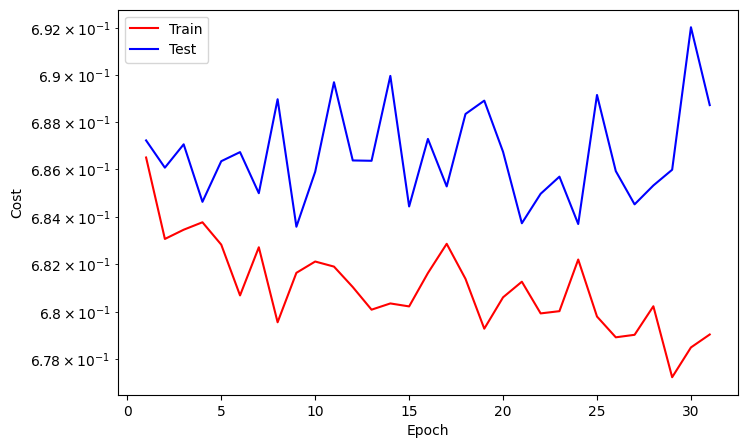

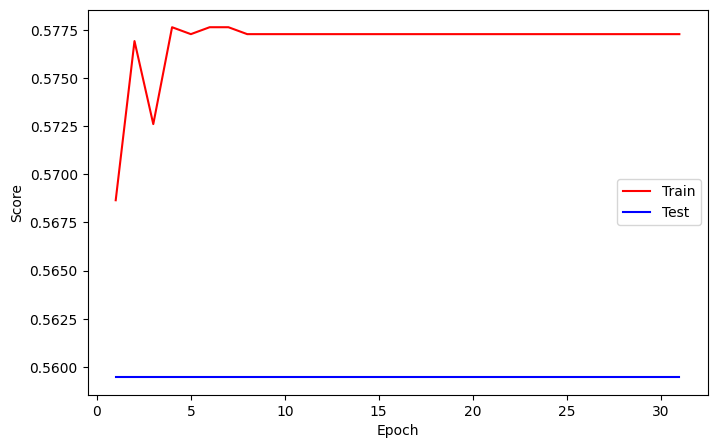

⏹️ Training dihentikan oleh early stopping.

In [213]:
from train_and_evaluate import train_and_evaluate_multi_label

train_and_evaluate_multi_label(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optim=optim,
    config=config,
    device=device,
    labels=labels,          
    callback=callback
)

In [214]:
from evaluate import evaluate_multi_label

hsl = evaluate_multi_label(model, test_loader, ['bad', 'good'],criterion, device, config.threshold)

       📊 Evaluasi Model            🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓      Accuracy      
┃ Metrik              ┃  Nilai ┃ ┏━━━━━━━┳━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Akurasi ┃
│ 🔹 Overall Accuracy │ 0.5595 │ ┡━━━━━━━╇━━━━━━━━━┩
│ ✅ Subset  Accuracy │ 0.5595 │ │  bad  │ 0.5595  │
│ 💥 Loss (avg)       │ 0.6845 │ │ good  │ 0.5595  │
│ 📉 Hamming Loss     │ 0.4405 │ └───────┴─────────┘
│ ⚖️  Micro F1-score   │ 0.5595 │                    
│ 📈 Macro F1-score   │ 0.3588 │                    
└─────────────────────┴────────┘

In [215]:
hsl['df'].head(100)

,Target,Prediksi,Benar (%)
0,"[0.0, 1.0]","[0.0, 1.0]",100.0
1,"[0.0, 1.0]","[0.0, 1.0]",100.0
2,"[1.0, 0.0]","[0.0, 1.0]",0.0
3,"[0.0, 1.0]","[0.0, 1.0]",100.0
4,"[0.0, 1.0]","[0.0, 1.0]",100.0
...,...,...,...
95,"[0.0, 1.0]","[0.0, 1.0]",100.0
96,"[1.0, 0.0]","[0.0, 1.0]",0.0
97,"[0.0, 1.0]","[0.0, 1.0]",100.0
98,"[0.0, 1.0]","[0.0, 1.0]",100.0
